# Animated Track Animation

The goal of this notebook is to compare the two drivers on an animated track display.  
It is inspired by the Live Timing feature of the official Formula One website.

### 1. Import packages and Load Session

In [10]:
import fastf1 as ff1
from fastf1 import plotting

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

from utility import set_dark

ff1.Cache.enable_cache('./data/cache')

import warnings # for clearner outputs
warnings.filterwarnings("ignore")

In [11]:
season = 2025
race = 'Monza'
session_type = 'Q' # 'FP1', 'FP2', 'FP3', 'Q', 'S', 'R'

session = ff1.get_session(season, race, session_type)
session.load()

core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '44', '63', '12', '5', '14', '22', '87', '27', '55', '23', '31', '6', '18', '43', '10', '30']


### 2. Retrieve Relevant Data

The _telemetry data_ from `FastF1` provides x, y, z coordinates for the relative car position.   
This should be? useful to plot each vehicle on the track map.

In [12]:
driver1 = 'VER'
driver2 = 'NOR'
driver1_color = plotting.get_driver_color(driver1, session=session)
driver2_color = plotting.get_driver_color(driver2, session=session)

# fastest lap 
driver1_fastest = session.laps.pick_drivers(driver1).pick_fastest()
driver2_fastest = session.laps.pick_drivers(driver2).pick_fastest()

# telemetry data
tel1 = driver1_fastest.get_telemetry()
tel2 = driver2_fastest.get_telemetry()

tel1

,Date,SessionTime,DriverAhead,DistanceToDriverAhead,Time,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Distance,RelativeDistance,Status,X,Y,Z
2,2025-09-06 15:00:53.955,0 days 01:13:33.378000,,802.070000,0 days 00:00:00,11381.404580,321.645455,8,100.0,False,8,interpolation,0.018979,0.000003,OnTrack,-1373.650597,-676.336105,1871.232164
3,2025-09-06 15:00:54.242,0 days 01:13:33.665000,,802.070000,0 days 00:00:00.287000,11459.024983,322.950000,8,100.0,False,8,pos,25.822479,0.004472,OnTrack,-1346.000000,-352.000000,1873.000000
4,2025-09-06 15:00:54.253,0 days 01:13:33.676000,,802.070000,0 days 00:00:00.298000,11462.000000,323.000000,8,100.0,False,14,car,26.816111,0.004644,OnTrack,-1345.304479,-344.042629,1873.058849
5,2025-09-06 15:00:54.414,0 days 01:13:33.837000,4,802.070000,0 days 00:00:00.459000,11415.000000,326.000000,8,100.0,False,12,car,41.395556,0.007169,OnTrack,-1337.809285,-260.635587,1873.822443
6,2025-09-06 15:00:54.502,0 days 01:13:33.925000,4,797.767775,0 days 00:00:00.547000,11446.376061,326.490251,8,100.0,False,12,pos,49.387330,0.008553,OnTrack,-1333.000000,-207.000000,1874.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
584,2025-09-06 15:02:12.422,0 days 01:14:51.845000,4,630.807216,0 days 00:01:18.467000,11190.337507,314.778126,8,100.0,False,8,pos,5725.894955,0.991603,OnTrack,-1398.000000,-979.000000,1870.000000
585,2025-09-06 15:02:12.493,0 days 01:14:51.916000,4,628.499722,0 days 00:01:18.538000,11193.000000,315.000000,8,100.0,False,8,car,5732.114722,0.992680,OnTrack,-1393.104911,-914.946997,1870.436860
586,2025-09-06 15:02:12.582,0 days 01:14:52.005000,4,625.508327,0 days 00:01:18.627000,11214.508380,315.370834,8,100.0,False,8,pos,5739.916998,0.994032,OnTrack,-1387.000000,-836.000000,1871.000000
587,2025-09-06 15:02:12.733,0 days 01:14:52.156000,4,620.433056,0 days 00:01:18.778000,11251.000000,316.000000,8,100.0,False,10,car,5753.181389,0.996329,OnTrack,-1376.364779,-703.244855,1871.685519


In [13]:
# z coord is not need because the track map is 2D.
driver1_x = tel1['X'].values
driver1_y = tel1['Y'].values
driver2_x = tel2['X'].values
driver2_y = tel2['Y'].values

driver1_time = tel1['Time'].dt.total_seconds().values # .values makes it a numpy array. otherwise, just a laptime in seconds
driver2_time = tel2['Time'].dt.total_seconds().values

# driver1_time

### 3. Track & Driver Plots

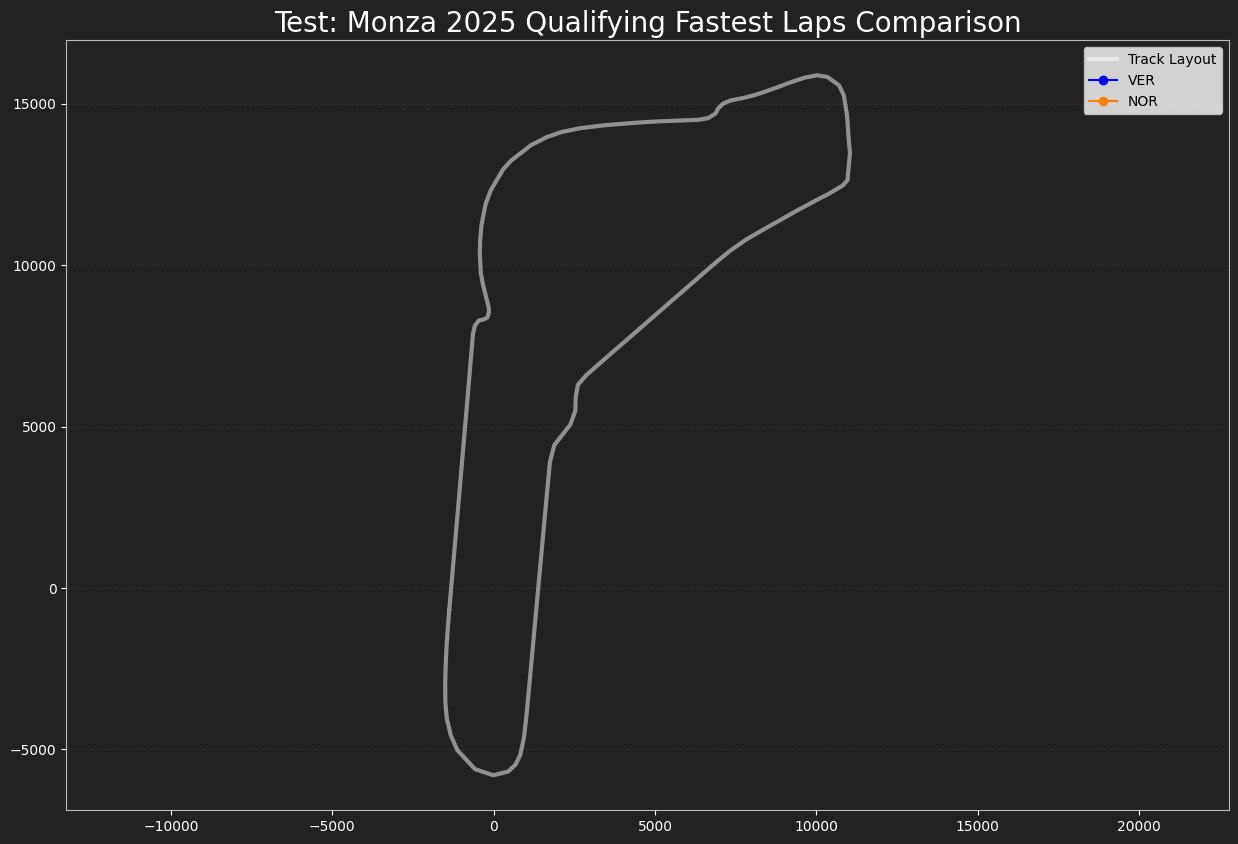

In [24]:
fig, ax = plt.subplots(figsize=(15, 10))
set_dark(ax)

# track layout : maybe use the circuit info instead of driver1 data in the future. 
step = 5
ax.plot(driver1_x[::step], driver1_y[::step], color='white', label='Track Layout', linewidth=3, alpha=0.5) 

# driver points (dots) 
driver1_point, = ax.plot([], [], marker='o', color=driver1_color, label=f"{driver1}")
driver2_point, = ax.plot([], [], marker='o', color=driver2_color, label=f"{driver2}")

ax.set_title("Test: Monza 2025 Qualifying Fastest Laps Comparison", fontsize=20)
ax.legend(facecolor='white')
ax.grid(axis='y', alpha=0.1, linestyle='--')
ax.set_aspect(1, adjustable='datalim') # equal scaling of x and y axes.

`get_pos` function    


Find the car's position at the given time. 
- `time`: the time you want to find the car pos.
- `time_arr`: time array from the telemetry data.
- `x_arr`: x position array from the telemtery data.
- `y_arr`: y position array from the telemetry data. 

*This method is searched on the Internet to get the position of the car when `time` is somewhere between the `time_arr` elements. 

___Linear Interpolation___
$$
y(x)
=
y_0
+
\frac{y_1 - y_0}{x_1 - x_0}
\,(x - x_0),
\qquad
x \in [x_0, x_1]
$$

which is the linear function connecting the two points.

In [19]:
def get_pos(time, time_arr, x_arr, y_arr):
    # # if the given time is bigger than the last time element in the array, return the last position.
    # if time > time_arr[-1]:
    #     return x_arr[-1], y_arr[-1] 
    # idx = np.searchsorted(time_arr, time) # binary search to find the index where 'time' would fit in 'time_arr'
    # if idx == 0:
    #     return x_arr[0], y_arr[0]
    # if idx >= len(time_arr): # if idx out of bounds, return the last position.
    #     return x_arr[-1], y_arr[-1]

    # # linear interpolation 
    # # idx > 0 here. 
    
    # OR, using numpy function,
    x = np.interp(time, time_arr, x_arr)
    y = np.interp(time, time_arr, y_arr)
    return x, y

In [ ]:
# animation duration
max_time = max(driver1_time[-1], driver2_time[-1])
min_time = 0

# Number of frames for the animation
fps = 30
num_frames = int(max_time * fps)

def animate(frame):
    global driver1_trail_x, driver1_trail_y, driver2_trail_x, driver2_trail_y
    
    # current time in seconds
    curr_time = (frame / fps)
    
    # driver positions
    x1, y1 = get_pos(curr_time, driver1_time, driver1_x, driver1_y)
    x2, y2 = get_pos(curr_time, driver2_time, driver2_x, driver2_y)
    
    # update the location of driver points. 
    driver1_point.set_data([x1], [y1]) 
    driver2_point.set_data([x2], [y2])
    
    return driver1_point, driver2_point

# Create animation
anim = FuncAnimation(fig, animate, frames=num_frames, interval=1000/fps, blit=True, repeat=True) # blit: improve perf. , repeat: restart after the animation. 


In [26]:
# save as gif
writer = PillowWriter(fps=fps, metadata=dict(artist='Me'), bitrate=1800)
anim.save('test.gif', writer=writer)

plt.show()